<a href="https://colab.research.google.com/github/Vishal-Mungal/NNDLPRACTICAL/blob/main/NNDL_pr3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense, Flatten

In [10]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train , y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
print("training images" , x_train.shape)
print("training labels" , y_train.shape)
print("testing images" , x_test.shape)
print("testing labels" , y_test.shape)

training images (60000, 28, 28)
training labels (60000,)
testing images (10000, 28, 28)
testing labels (10000,)


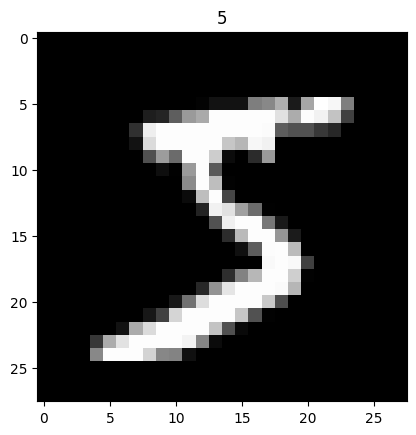

In [18]:
plt.imshow(x_train[0], cmap='gray')

plt.title(y_train[0])
plt.show()

In [19]:
#normalization
x_train, x_test = x_train / 255.0, x_test / 255.0

In [21]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
#compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
history = model.fit(x_train,y_train,epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9712 - loss: 0.0969 - val_accuracy: 0.9629 - val_loss: 0.1220
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9725 - loss: 0.0918 - val_accuracy: 0.9646 - val_loss: 0.1162
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9739 - loss: 0.0872 - val_accuracy: 0.9650 - val_loss: 0.1134
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9752 - loss: 0.0831 - val_accuracy: 0.9645 - val_loss: 0.1157
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0791 - val_accuracy: 0.9672 - val_loss: 0.1078
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9773 - loss: 0.0750 - val_accuracy: 0.9676 - val_loss: 0.1080
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9781 - loss: 0.0717 - val_accuracy: 0.9648 - val_loss: 0.1146
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9787 - loss: 0.0694 - 

In [34]:
#make prediction
y_pred=model.predict(x_test)
y_pred=np.argmax(y_pred,axis=1)
print(y_pred)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[7 2 1 ... 4 5 6]


In [36]:
#evaluation
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

print('\nTest Accuracy:', test_acc)

313/313 - 0s - 1ms/step - accuracy: 0.9629 - loss: 0.1222

Test Accuracy: 0.9628999829292297


In [38]:
print("predicted digits", y_pred)
print("actual digits", y_test)

predicted digits [7 2 1 ... 4 5 6]
actual digits [7 2 1 ... 4 5 6]


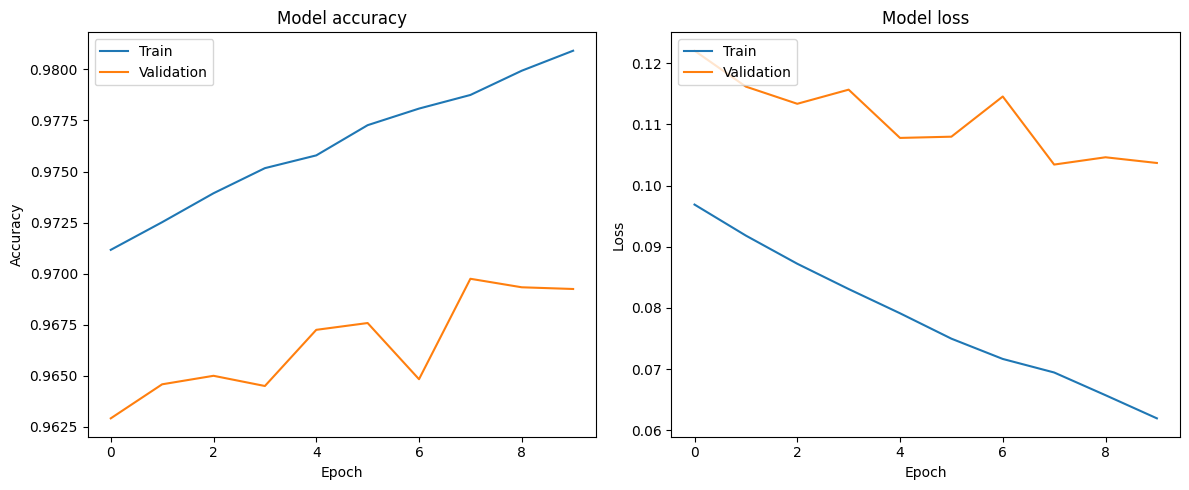

In [41]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()